In [1]:
import pandas as pd
df_clean = pd.read_pickle('../data/cleaned_loans.pkl')
print(df_clean.shape)

(1342552, 98)


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

scorecard_features = ['int_rate', 'dti', 'loan_amnt', 'log_annual_inc']   # <-- ADDED: was missing

woe_cols = [c + '_woe' for c in scorecard_features]
df_clean[woe_cols] = df_clean[woe_cols].astype(float)   # <-- ADDED: prevents the category dtype error

X = df_clean[woe_cols]
y = df_clean['default']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_scores = cross_val_score(log_model, X, y, cv=cv, scoring='roc_auc')

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

print("Logistic Regression AUC per fold:", log_scores.round(4))
print(f"Logistic Regression: mean AUC = {log_scores.mean():.4f} (+/- {log_scores.std():.4f})")
print()
print("XGBoost AUC per fold:", xgb_scores.round(4))
print(f"XGBoost: mean AUC = {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")

Logistic Regression AUC per fold: [0.6665 0.6683 0.6701 0.6688 0.6681]
Logistic Regression: mean AUC = 0.6684 (+/- 0.0012)

XGBoost AUC per fold: [0.6922 0.6932 0.6948 0.6935 0.6942]
XGBoost: mean AUC = 0.6936 (+/- 0.0009)


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='roc_auc')

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6, n_jobs=-1)
rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"Decision Tree: mean AUC = {dt_scores.mean():.4f} (+/- {dt_scores.std():.4f})")
print(f"Random Forest: mean AUC = {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")

Decision Tree: mean AUC = 0.6870 (+/- 0.0012)
Random Forest: mean AUC = 0.6901 (+/- 0.0012)


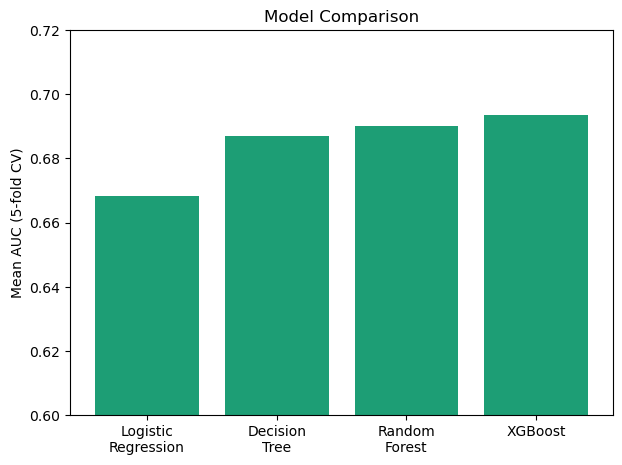

In [5]:
import matplotlib.pyplot as plt
import os

os.makedirs('../figures', exist_ok=True)

names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
aucs = [log_scores.mean(), dt_scores.mean(), rf_scores.mean(), xgb_scores.mean()]
plt.figure(figsize=(7, 5))
plt.bar(names, aucs, color='#1D9E75')
plt.ylabel('Mean AUC (5-fold CV)'); plt.title('Model Comparison'); plt.ylim(0.6, 0.72)
plt.savefig('../figures/model_comparison.png', dpi=150)
plt.show()